In [9]:
import pandas as pd


In [10]:
import pandas as pd

df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [11]:
df.shape

(7043, 33)

In [12]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [14]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [15]:
df_clean = df.copy()

columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Zip Code",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.head()

df_clean.shape

(7043, 23)

## Missing Values Analysis

In [16]:
# Check missing values in each column
missing_values = df_clean.isnull().sum()

missing_values

State                0
City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

In [17]:
df_clean.isnull().sum()

State                0
City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

## Duplicate Records

In [18]:
df_clean.duplicated().sum()

np.int64(0)

In [19]:
df_clean["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

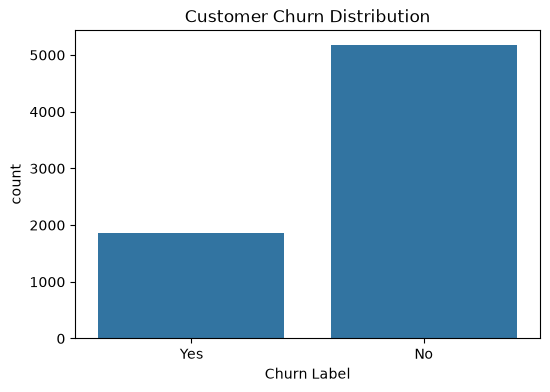

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.show()

## Business Insight 1: Churn by Gender

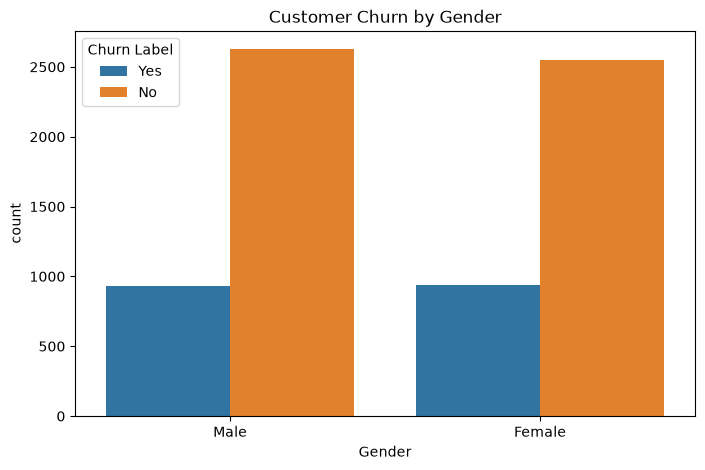

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Gender",
    hue="Churn Label"
)

plt.title("Customer Churn by Gender")
plt.show()

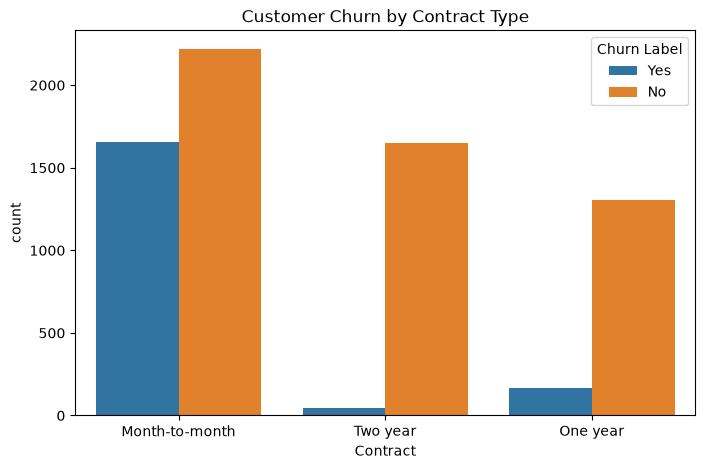

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn Label"
)

plt.title("Customer Churn by Contract Type")
plt.show()

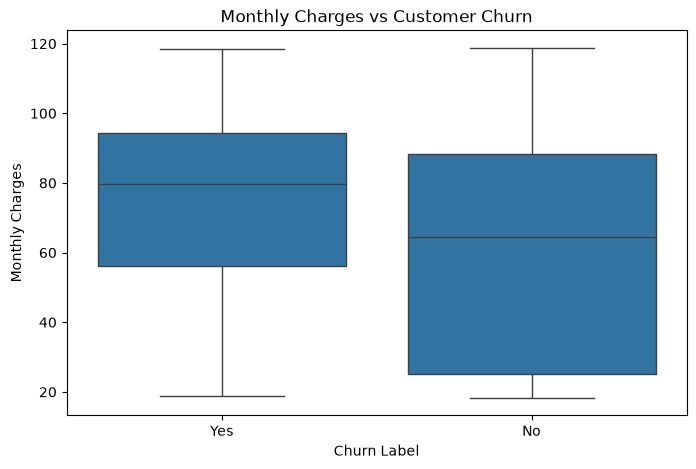

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.show()

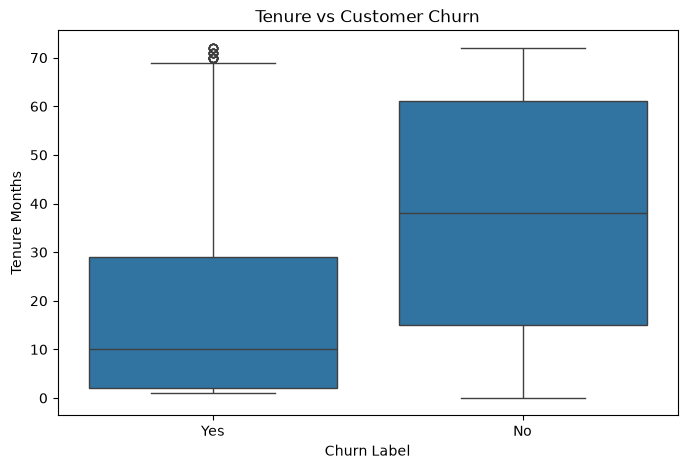

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure vs Customer Churn")
plt.show()

# Feature Engineering

In [25]:
# Separate categorical and numerical columns

categorical_cols = df_clean.select_dtypes(include=["object", "string"]).columns

numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumerical Columns:")
print(numerical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))

Categorical Columns:
Index(['State', 'City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Total Charges', 'Churn Label'],
      dtype='str')

Number of categorical columns: 20

Numerical Columns:
Index(['Tenure Months', 'Monthly Charges', 'CLTV'], dtype='str')

Number of numerical columns: 3


## Business Insight 5: Churn by Internet Service

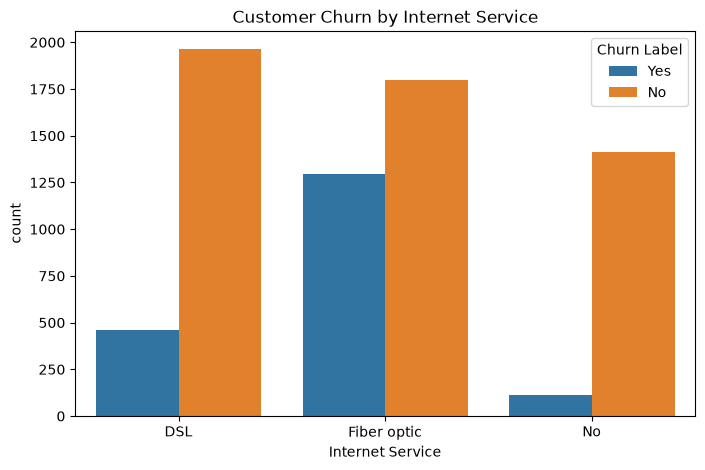

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Customer Churn by Internet Service")
plt.show()

### Observation

Customers using Fiber Optic internet have a significantly higher churn rate than DSL users.

Customers without internet service exhibit the lowest churn.

### Business Recommendation

Improve service quality, pricing, or customer support for Fiber Optic users, as they represent the highest-risk customer segment.

## Business Insight 6: Churn by Payment Method

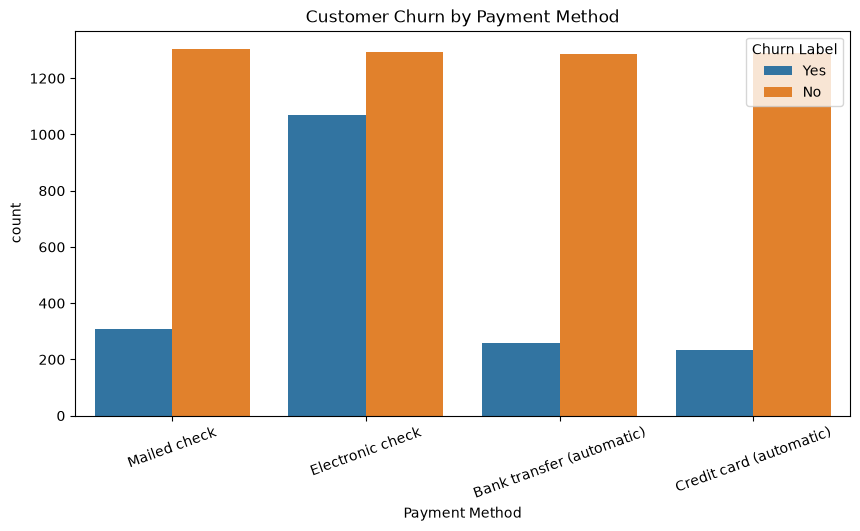

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Payment Method",
    hue="Churn Label"
)

plt.xticks(rotation=20)

plt.title("Customer Churn by Payment Method")
plt.show()

### Observation

Customers paying through Electronic Check show a much higher churn rate compared to customers using automatic payment methods.

### Business Recommendation

Encourage customers to switch to automatic payment options by offering cashback or discounts.

## Business Insight 7: Senior Citizens

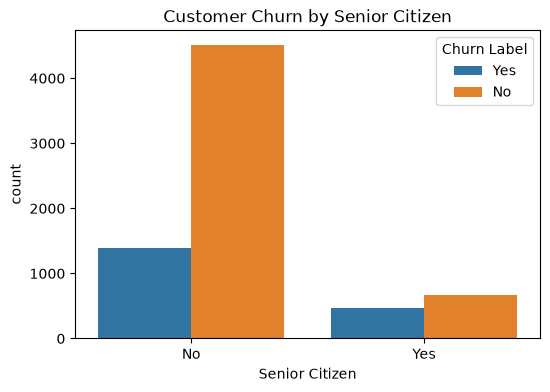

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Senior Citizen",
    hue="Churn Label"
)

plt.title("Customer Churn by Senior Citizen")
plt.show()

### Observation

Senior Citizens have a relatively higher proportion of churn compared to non-senior customers.

### Business Recommendation

Provide dedicated customer support and personalized plans for senior customers.

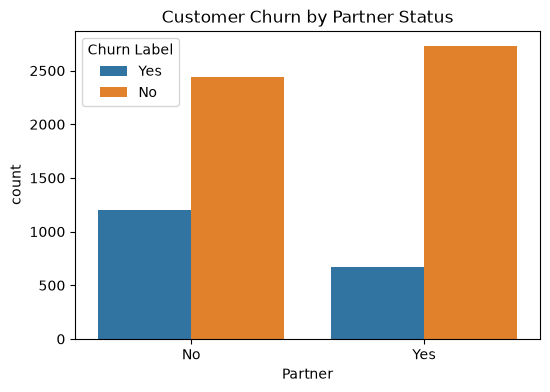

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Partner",
    hue="Churn Label"
)

plt.title("Customer Churn by Partner Status")
plt.show()

### Observation

Customers without partners are more likely to churn than customers with partners.

### Business Recommendation

Introduce family plans and bundled offers to improve customer retention.

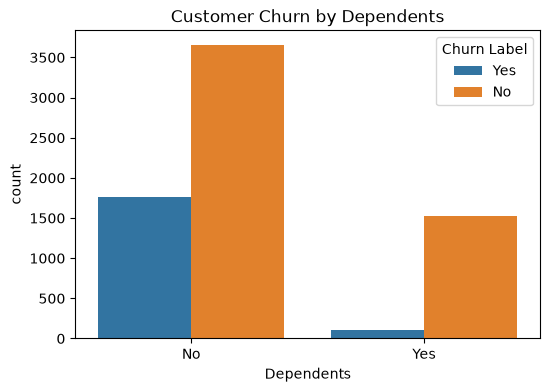

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Dependents",
    hue="Churn Label"
)

plt.title("Customer Churn by Dependents")
plt.show()

### Observation

Customers with dependents have a much lower churn rate.

### Business Recommendation

Family-oriented subscription plans appear to increase customer loyalty.

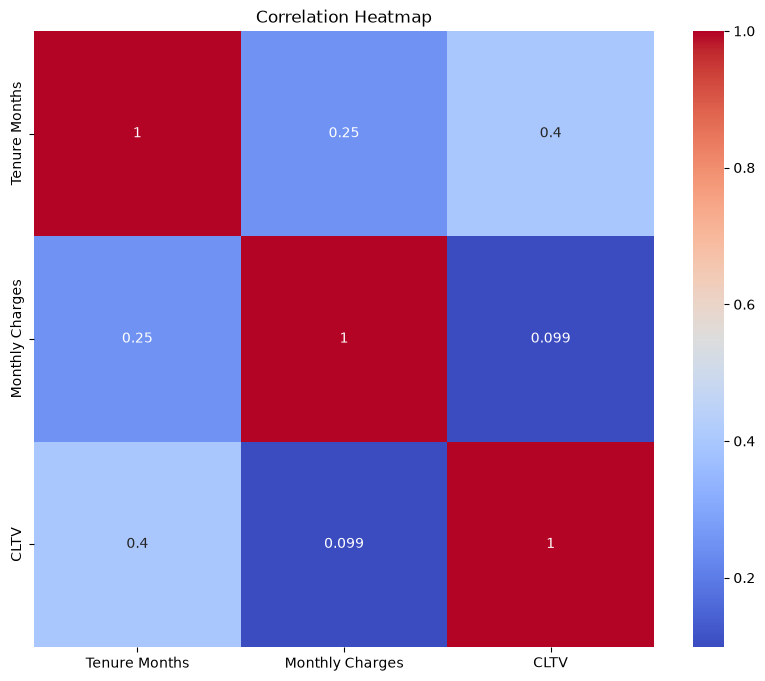

In [31]:
plt.figure(figsize=(10,8))

numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

Tenure shows the strongest positive relationship with Customer Lifetime Value (CLTV).

Monthly Charges have only a weak relationship with CLTV.

### Business Recommendation

Retaining customers for a longer duration increases overall customer lifetime value.

# Feature Engineering

In [32]:
df_model = df_clean.copy()

df_model.head()

,State,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,California,Los Angeles,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,California,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,California,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,5372
3,California,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,California,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,5340


In [33]:
df_model.dtypes

State                    str
City                     str
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
CLTV                   int64
dtype: object

# Data Type Conversion

In [34]:
df_model["Total Charges"] = pd.to_numeric(
    df_model["Total Charges"],
    errors="coerce"
)

df_model["Total Charges"].dtype

dtype('float64')

In [35]:
df_model.isnull().sum()

State                 0
City                  0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Label           0
CLTV                  0
dtype: int64

In [36]:
df_model[df_model["Total Charges"].isnull()]

,State,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
2234,California,San Bernardino,Female,No,Yes,No,0,No,No phone service,DSL,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,2578
2438,California,Independence,Male,No,No,No,0,Yes,No,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,5504
2568,California,San Mateo,Female,No,Yes,No,0,Yes,No,DSL,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,2048
2667,California,Cupertino,Male,No,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,4950
2856,California,Redcrest,Female,No,Yes,No,0,No,No phone service,DSL,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,4740
4331,California,Los Angeles,Male,No,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,2019
4687,California,Sun City,Male,No,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,2299
5104,California,Ben Lomond,Female,No,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,3763
5719,California,La Verne,Male,No,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,4890
6772,California,Bell,Female,No,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,2342


In [37]:
df_model["Total Charges"] = df_model["Total Charges"].fillna(0)

In [38]:
df_model.isnull().sum()

State                0
City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

In [39]:
df_model = df_model.drop(columns=["CLTV"])

In [40]:
df_model.shape

(7043, 22)

In [41]:
for column in df_model.select_dtypes(include="object").columns:
    print("=" * 50)
    print(column)
    print(df_model[column].unique())

State
<ArrowStringArray>
['California']
Length: 1, dtype: str
City
<ArrowStringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str
Gender
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Senior Citizen
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Partner
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Phone Service
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Multiple Lines
<ArrowStringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
Internet Service
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 

C:\Users\SAYONI\AppData\Local\Temp\ipykernel_21876\2247567052.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_model.select_dtypes(include="object").columns:


In [42]:
df_model = df_model.drop(columns=["State"])

df_model.shape

(7043, 21)

In [43]:
df_model["Churn Label"] = df_model["Churn Label"].map({
    "No":0,
    "Yes":1
})

df_model["Churn Label"].value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [44]:
X = df_model.drop("Churn Label", axis=1)

y = df_model["Churn Label"]

print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


In [45]:
categorical_cols = X.select_dtypes(include=["object","string"]).columns

numerical_cols = X.select_dtypes(include=["int64","float64"]).columns

print("Categorical")
print(categorical_cols)

print()

print("Numerical")
print(numerical_cols)

Categorical
Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='str')

Numerical
Index(['Tenure Months', 'Monthly Charges', 'Total Charges'], dtype='str')


In [46]:
print(categorical_cols)
print(numerical_cols)

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='str')
Index(['Tenure Months', 'Monthly Charges', 'Total Charges'], dtype='str')


In [47]:
df_model = df_model.drop(columns=["City"])

X = df_model.drop("Churn Label", axis=1)
y = df_model["Churn Label"]

print(X.shape)

(7043, 19)


In [48]:
df_model = df_model.drop(columns=["City"])

X = df_model.drop("Churn Label", axis=1)
y = df_model["Churn Label"]

print(X.shape)

KeyError: "['City'] not found in axis"

In [ ]:
print(df_model.columns)


Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'],
      dtype='str')


In [ ]:
X = df_model.drop("Churn Label", axis=1)
y = df_model["Churn Label"]

print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 19)
Testing Features  : (1409, 19)
Training Labels   : (5634,)
Testing Labels    : (1409,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

In [ ]:
categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [ ]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [ ]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [ ]:
y_pred = logistic_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8019872249822569

Confusion Matrix
[[917 118]
 [161 213]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=6
    ))
])

In [ ]:
decision_tree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [ ]:
y_pred_dt = decision_tree.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print()

print(confusion_matrix(y_test, y_pred_dt))
print()

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7842441447835344

[[889 146]
 [158 216]]

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1035
           1       0.60      0.58      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
random_forest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [ ]:
y_pred_rf = random_forest.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()

print(confusion_matrix(y_test, y_pred_rf))
print()

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8041163946061036

[[926 109]
 [167 207]]

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [ ]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print()

print(confusion_matrix(y_test, y_pred_xgb))
print()

print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7984386089425124

[[917 118]
 [166 208]]

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.56      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    random_forest,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
0.6022059027259852


In [ ]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print()

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_best))
print()

print("Classification Report")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.8048261178140526

Confusion Matrix
[[929 106]
 [169 205]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
import joblib

joblib.dump(best_rf, "../models/customer_churn_model.pkl")

['../models/customer_churn_model.pkl']

In [ ]:
loaded_model = joblib.load("../models/customer_churn_model.pkl")

prediction = loaded_model.predict(X_test[:5])

print(prediction)

[0 1 0 0 0]


In [ ]:
import numpy as np

df_model["Avg Monthly Spend"] = (
    df_model["Total Charges"] /
    df_model["Tenure Months"]
)

df_model["Avg Monthly Spend"] = (
    df_model["Avg Monthly Spend"]
    .replace([np.inf, -np.inf],0)
)

df_model["Long Term Customer"] = (
    df_model["Tenure Months"] >= 24
).astype(int)

df_model["High Monthly Bill"] = (
    df_model["Monthly Charges"] >
    df_model["Monthly Charges"].median()
).astype(int)

df_model["Contract Length"] = (
    df_model["Contract"]
        .map({
            "Month-to-month":1,
            "One year":2,
            "Two year":3
        })
)

In [ ]:
service_cols = [
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df_model["Total Services"] = (
    df_model[service_cols] == "Yes"
).sum(axis=1)

In [ ]:
df_clean["CLTV"].head()

0    3239
1    2701
2    5372
3    5003
4    5340
Name: CLTV, dtype: int64

In [ ]:
import numpy as np

# Avoid division by zero
df_model["Avg Monthly Spend"] = (
    df_model["Total Charges"] /
    df_model["Tenure Months"].replace(0, 1)
)

# Long-term customer
df_model["Long Term Customer"] = (
    df_model["Tenure Months"] >= 24
).astype(int)

# High monthly bill
median_bill = df_model["Monthly Charges"].median()

df_model["High Monthly Bill"] = (
    df_model["Monthly Charges"] > median_bill
).astype(int)

# Count subscribed services
service_columns = [
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df_model["Total Services"] = (
    df_model[service_columns] == "Yes"
).sum(axis=1)

# Charges per service
df_model["Charges Per Service"] = (
    df_model["Monthly Charges"] /
    (df_model["Total Services"] + 1)
)

# ==========================
# Feature Engineering
# ==========================

In [ ]:
import numpy as np

# Average monthly spend
df_model["Avg Monthly Spend"] = (
    df_model["Total Charges"] /
    df_model["Tenure Months"].replace(0,1)
)

# Long-term customer
df_model["Long Term Customer"] = (
    df_model["Tenure Months"] >= 24
).astype(int)

# High monthly bill
median_bill = df_model["Monthly Charges"].median()

df_model["High Monthly Bill"] = (
    df_model["Monthly Charges"] > median_bill
).astype(int)

service_columns = [

"Phone Service",
"Multiple Lines",
"Online Security",
"Online Backup",
"Device Protection",
"Tech Support",
"Streaming TV",
"Streaming Movies"

]

df_model["Total Services"] = (
df_model[service_columns] == "Yes"
).sum(axis=1)

df_model["Charges Per Service"] = (
df_model["Monthly Charges"] /
(df_model["Total Services"] + 1)
)

In [ ]:
df_model.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Avg Monthly Spend,Long Term Customer,High Monthly Bill,Contract Length,Total Services,Charges Per Service
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,54.075000,0,0,1,3,13.462500
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,75.825000,0,1,1,1,35.350000
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Electronic check,99.65,820.50,1,102.562500,0,1,1,5,16.608333
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Electronic check,104.80,3046.05,1,108.787500,1,1,1,6,14.971429
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Bank transfer (automatic),103.70,5036.30,1,102.781633,1,1,1,6,14.814286


In [ ]:
X = df_model.drop("Churn Label", axis=1)
y = df_model["Churn Label"]

In [ ]:
print(X.shape)
print(y.shape)

(7043, 25)
(7043,)


In [ ]:
categorical_cols = X.select_dtypes(include=["object","string"]).columns

numerical_cols = X.select_dtypes(include=["int64","float64"]).columns

print(categorical_cols)
print(numerical_cols)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')
Index(['Tenure Months', 'Monthly Charges', 'Total Charges',
       'Avg Monthly Spend', 'Long Term Customer', 'High Monthly Bill',
       'Contract Length', 'Total Services', 'Charges Per Service'],
      dtype='str')


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(

[
("num", StandardScaler(), numerical_cols),

("cat",
OneHotEncoder(handle_unknown="ignore"),
categorical_cols)

]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42,

stratify=y

)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(

steps=[

("preprocessor", preprocessor),

("classifier",

RandomForestClassifier(

random_state=42,

class_weight="balanced",

n_estimators=300,

max_depth=12,

min_samples_leaf=2,

min_samples_split=5

))

]

)

In [ ]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['Gender','Senior Citizen','Partner',...,'Contract Length', 'Total Services','Charges Per Service']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test,y_pred))
print()

print(confusion_matrix(y_test,y_pred))
print()

print(classification_report(y_test,y_pred))

Accuracy: 0.7643718949609652

[[795 240]
 [ 92 282]]

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

# probability of churn
y_prob = rf_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

pr_auc = average_precision_score(y_test, y_prob)

print("ROC-AUC :", round(roc_auc,4))
print("PR-AUC  :", round(pr_auc,4))

ROC-AUC : 0.8483
PR-AUC  : 0.6603


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Probability of churn
y_prob = rf_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.02)

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.30,0.465116,0.909091,0.615385
1,0.32,0.477952,0.898396,0.623955
2,0.34,0.482456,0.882353,0.623819
3,0.36,0.484985,0.863636,0.621154
4,0.38,0.494590,0.855615,0.626836
5,0.40,0.506410,0.844920,0.633267
6,0.42,0.512356,0.831551,0.634047
7,0.44,0.521295,0.818182,0.636837
8,0.46,0.532977,0.799465,0.639572
9,0.48,0.536900,0.778075,0.635371


                                 Feature  Importance
8               num__Charges Per Service    0.104246
6                   num__Contract Length    0.096746
0                     num__Tenure Months    0.082945
43          cat__Contract_Month-to-month    0.076508
2                     num__Total Charges    0.072373
1                   num__Monthly Charges    0.058667
3                 num__Avg Monthly Spend    0.057417
25               cat__Online Security_No    0.039921
16                   cat__Dependents_Yes    0.033309
45                cat__Contract_Two year    0.032208
15                    cat__Dependents_No    0.032084
34                  cat__Tech Support_No    0.027244
4                num__Long Term Customer    0.024239
23     cat__Internet Service_Fiber optic    0.024208
50  cat__Payment Method_Electronic check    0.021734


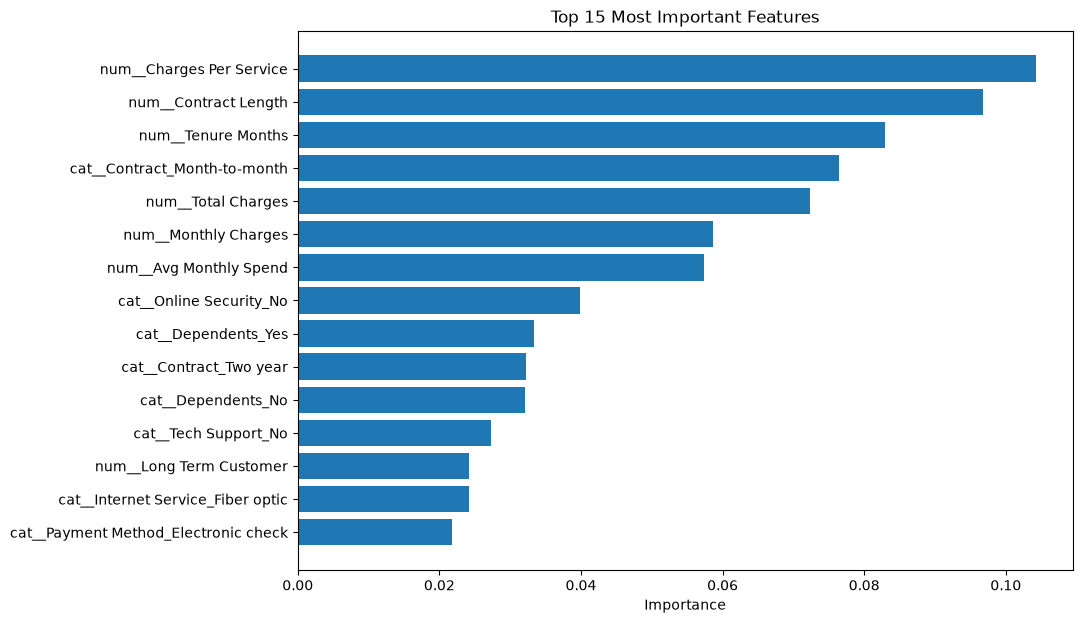

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances
importances = rf_model.named_steps["classifier"].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show Top 15
print(feature_importance.head(15))

# Plot
plt.figure(figsize=(10,7))
plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Most Important Features")
plt.show()

In [ ]:
df_model["Has Internet"] = (
    df_model["Internet Service"] != "No"
).astype(int)

In [ ]:
support_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df_model["Support Count"] = (
    df_model[support_cols] == "Yes"
).sum(axis=1)

In [ ]:
df_model["Family Size"] = (
    (df_model["Partner"] == "Yes").astype(int) +
    (df_model["Dependents"] == "Yes").astype(int)
)

In [ ]:
median_charge = df_model["Monthly Charges"].median()

df_model["High Monthly Charge"] = (
    df_model["Monthly Charges"] > median_charge
).astype(int)

In [ ]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import shap
import matplotlib.pyplot as plt

d:\PROJECTS\AI INTERN\CUSTOMER CHURN PREDICTION\AI-Customer-Retention-Platform\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import joblib

model = joblib.load("../models/customer_churn_model.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [ ]:
preprocessor = model.named_steps["preprocessor"]
rf = model.named_steps["classifier"]

In [ ]:
print(type(preprocessor))
print(type(rf))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [52]:
print(type(model))
print(type(preprocessor))
print(type(rf))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [54]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Churn Label", axis=1)
y = df_model["Churn Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [55]:
X_test_processed = preprocessor.transform(X_test)

print(type(X_test_processed))
print(X_test_processed.shape)

<class 'numpy.ndarray'>
(1409, 46)


In [56]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:10])

46
['num__Tenure Months' 'num__Monthly Charges' 'num__Total Charges'
 'cat__Gender_Female' 'cat__Gender_Male' 'cat__Senior Citizen_No'
 'cat__Senior Citizen_Yes' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No']


In [57]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_processed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [58]:
print(shap_values.shape)

(1409, 46, 2)


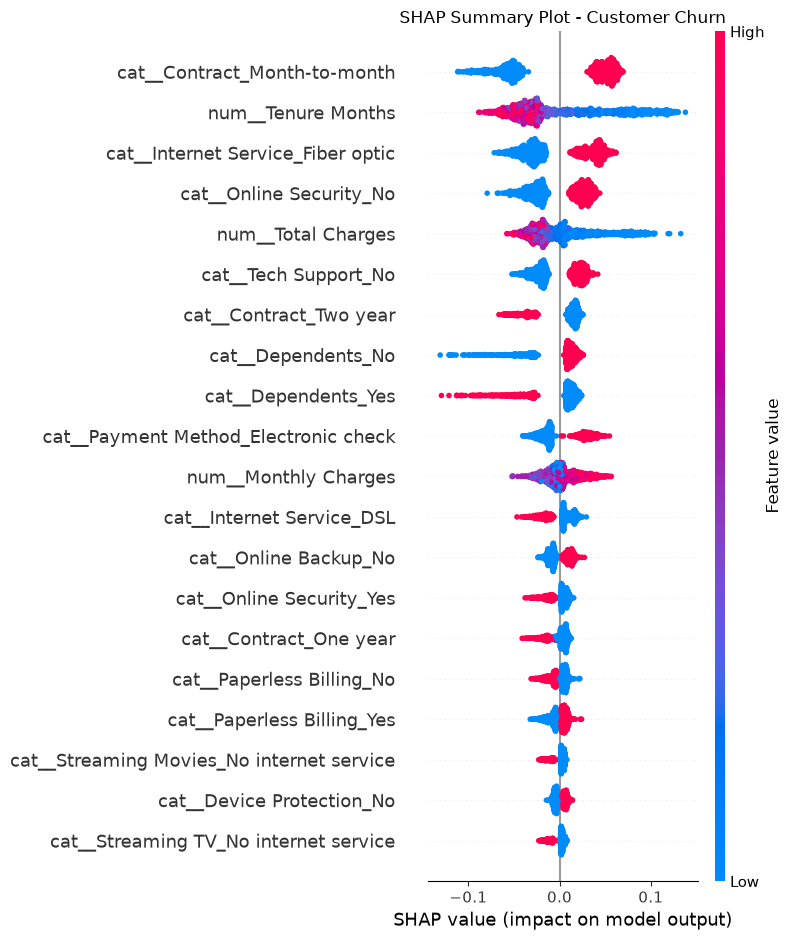

In [59]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values[:, :, 1],   # Churn class
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Customer Churn")
plt.tight_layout()
plt.show()

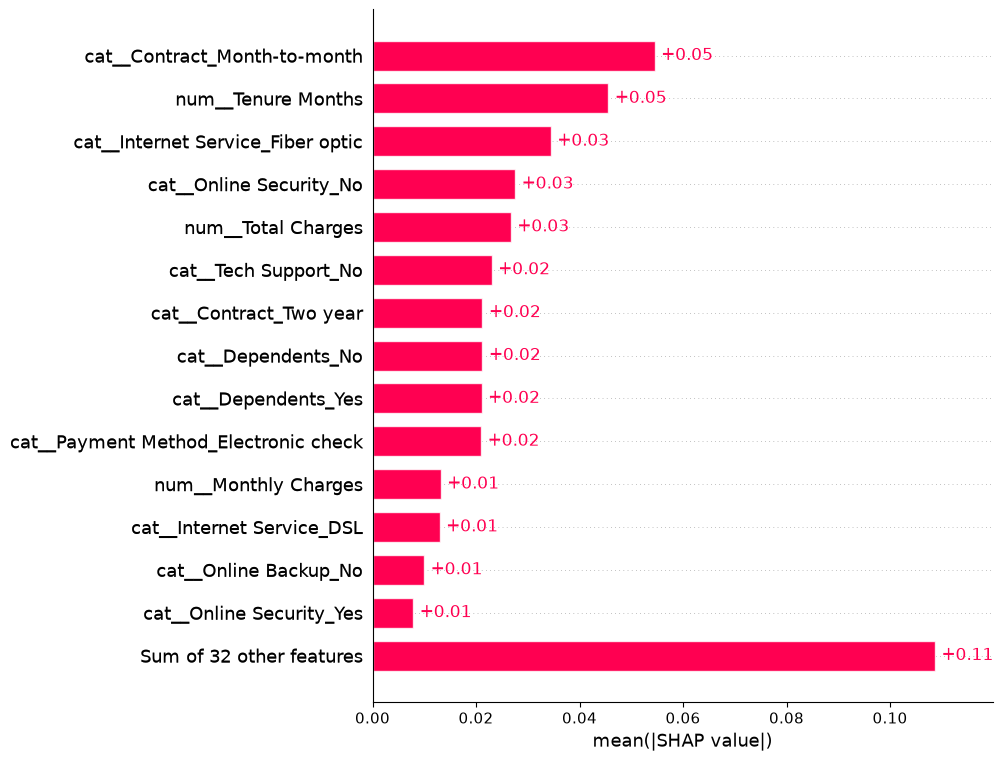

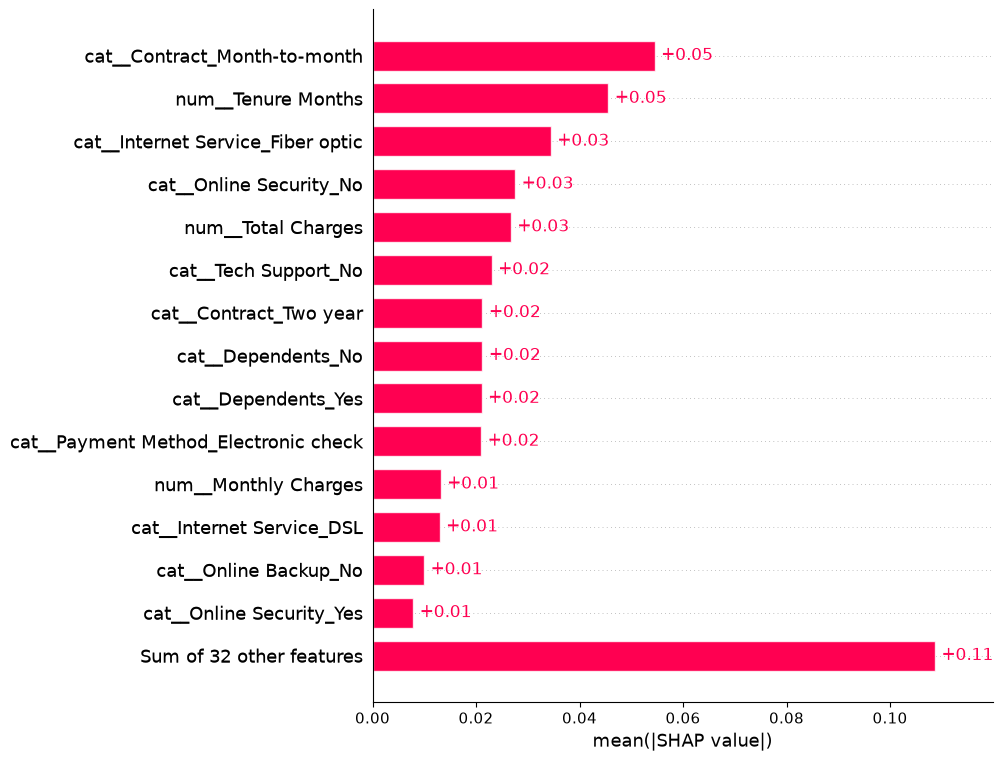

In [61]:
import shap
import matplotlib.pyplot as plt

shap.plots.bar(
    shap.Explanation(
        values=shap_values[:, :, 1],
        data=X_test_processed,
        feature_names=feature_names
    ),
    max_display=15
)

shap.plots.bar(
    shap.Explanation(
        values=shap_values[:,:,1],
        data=X_test_processed,
        feature_names=feature_names
    ),
    max_display=15
)

In [62]:
customer_index = 0

print("Actual Churn :", y_test.iloc[customer_index])

print("Predicted Probability :", 
      rf.predict_proba(X_test_processed[customer_index].reshape(1,-1))[0][1])

print("Prediction :",
      rf.predict(X_test_processed[customer_index].reshape(1,-1))[0])

Actual Churn : 0
Predicted Probability : 0.03424143399660445
Prediction : 0


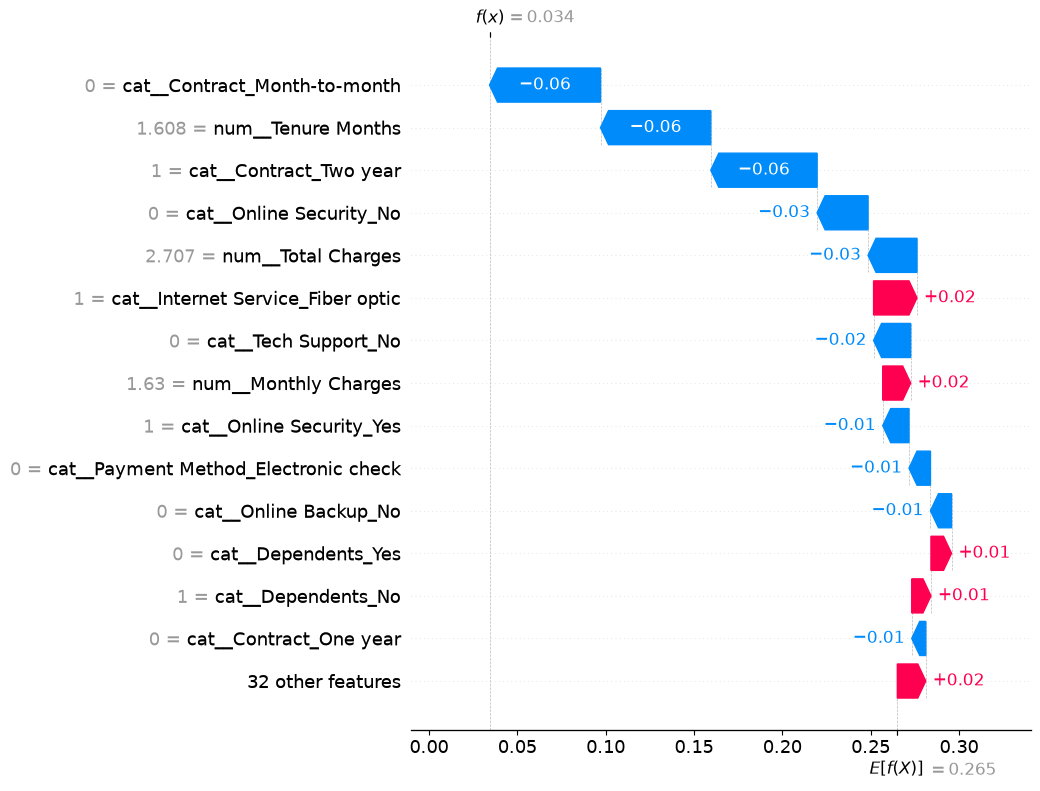

In [63]:
customer_index = 0

explanation = shap.Explanation(
    values=shap_values[customer_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_processed[customer_index],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=15)


In [64]:
# Find the customer with the highest predicted churn probability

probs = rf.predict_proba(X_test_processed)[:, 1]

customer_index = probs.argmax()

print("Customer Index:", customer_index)
print("Actual Churn:", y_test.iloc[customer_index])
print("Predicted Probability:", probs[customer_index])
print("Prediction:", rf.predict(X_test_processed[customer_index].reshape(1, -1))[0])

Customer Index: 1090
Actual Churn: 1
Predicted Probability: 0.8963949423345795
Prediction: 1


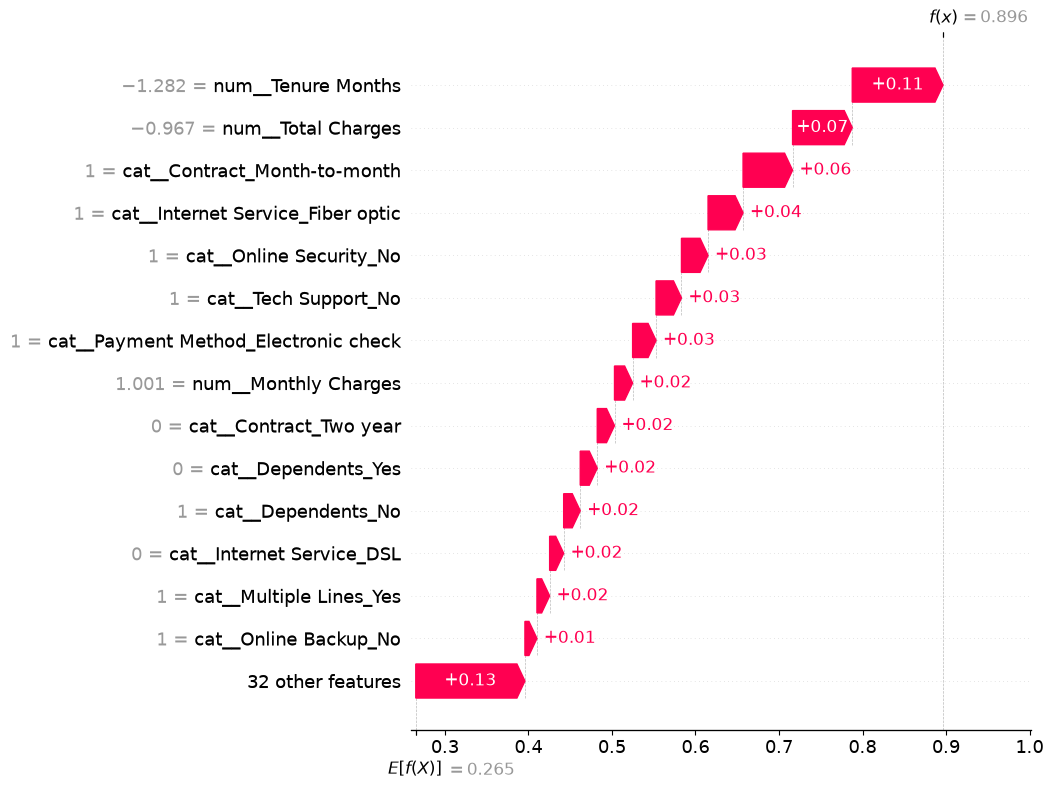

In [65]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf)

# SHAP values
shap_values = explainer.shap_values(X_test_processed)

# Display explanation for highest-risk customer
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_index, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_processed[customer_index],
        feature_names=feature_names
    ),
    max_display=15
)

In [66]:
# Probability of churn

risk_probability = rf.predict_proba(X_test_processed)[:,1]

risk_df = X_test.copy()

risk_df["Actual Churn"] = y_test.values
risk_df["Churn Probability"] = risk_probability

In [67]:
def risk_level(prob):

    if prob < 0.30:
        return "Low"

    elif prob < 0.60:
        return "Medium"

    elif prob < 0.80:
        return "High"

    else:
        return "Critical"


risk_df["Risk Level"] = risk_df["Churn Probability"].apply(risk_level)

risk_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual Churn,Churn Probability,Risk Level
2196,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.034241,Low
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.716964,High
3515,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.078194,Low
5162,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.427025,Medium
4642,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.037081,Low


In [68]:
risk_df["Risk Level"].value_counts()

Risk Level
Low         864
Medium      354
High        147
Critical     44
Name: count, dtype: int64

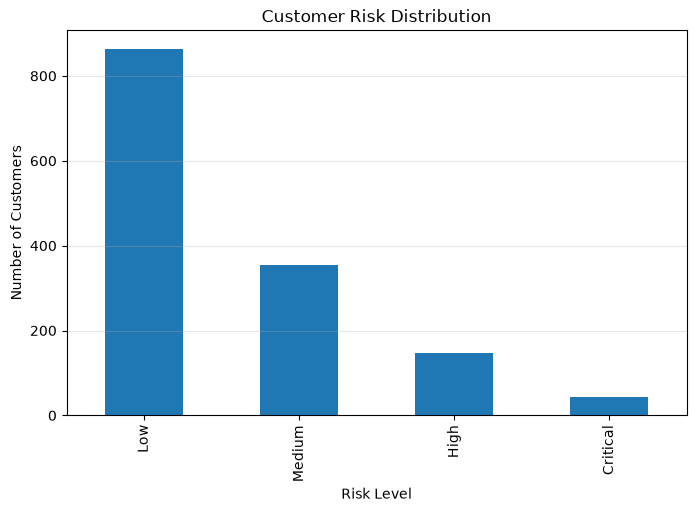

In [69]:
import matplotlib.pyplot as plt

risk_df["Risk Level"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [70]:
top_customers = risk_df.sort_values(
    by="Churn Probability",
    ascending=False
)

top_customers[
    [
        "Churn Probability",
        "Risk Level",
        "Actual Churn"
    ]
].head(10)

,Churn Probability,Risk Level,Actual Churn
886,0.896395,Critical,1
1818,0.886748,Critical,1
1203,0.886590,Critical,1
598,0.861214,Critical,1
1756,0.856076,Critical,1
1225,0.853109,Critical,1
684,0.852939,Critical,1
1213,0.850629,Critical,1
200,0.849823,Critical,1
453,0.845362,Critical,1


In [71]:
def recommend_action(row):

    risk = row["Risk Level"]

    contract = row["Contract"]

    monthly = row["Monthly Charges"]

    if risk == "Critical":

        if contract == "Month-to-month":

            return "Immediate retention call + 20% discount + Upgrade to yearly contract"

        else:

            return "Priority retention call + Loyalty reward"

    elif risk == "High":

        if monthly > 80:

            return "Offer personalized discount"

        else:

            return "Offer premium support"

    elif risk == "Medium":

        return "Send promotional email"

    else:

        return "No action required"

In [72]:
risk_df["Recommendation"] = risk_df.apply(
    recommend_action,
    axis=1
)

risk_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual Churn,Churn Probability,Risk Level,Recommendation
2196,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.034241,Low,No action required
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.716964,High,Offer personalized discount
3515,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.078194,Low,No action required
5162,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.427025,Medium,Send promotional email
4642,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.037081,Low,No action required


In [73]:
critical_customers = risk_df[
    risk_df["Risk Level"] == "Critical"
]

critical_customers[
    [
        "Risk Level",
        "Churn Probability",
        "Contract",
        "Monthly Charges",
        "Recommendation"
    ]
].head(10)

,Risk Level,Churn Probability,Contract,Monthly Charges,Recommendation
1760,Critical,0.821219,Month-to-month,74.50,Immediate retention call + 20% discount + Upgr...
3732,Critical,0.822702,Month-to-month,91.45,Immediate retention call + 20% discount + Upgr...
590,Critical,0.810621,Month-to-month,102.45,Immediate retention call + 20% discount + Upgr...
158,Critical,0.818255,Month-to-month,89.55,Immediate retention call + 20% discount + Upgr...
579,Critical,0.831816,Month-to-month,79.50,Immediate retention call + 20% discount + Upgr...
598,Critical,0.861214,Month-to-month,74.50,Immediate retention call + 20% discount + Upgr...
623,Critical,0.822558,Month-to-month,88.35,Immediate retention call + 20% discount + Upgr...
200,Critical,0.849823,Month-to-month,69.55,Immediate retention call + 20% discount + Upgr...
1782,Critical,0.806251,Month-to-month,85.00,Immediate retention call + 20% discount + Upgr...
1635,Critical,0.813965,Month-to-month,80.50,Immediate retention call + 20% discount + Upgr...


In [74]:
risk_df.groupby("Risk Level")["Recommendation"].value_counts()

Risk Level  Recommendation                                                      
Critical    Immediate retention call + 20% discount + Upgrade to yearly contract     44
High        Offer premium support                                                    82
            Offer personalized discount                                              65
Low         No action required                                                      864
Medium      Send promotional email                                                  354
Name: count, dtype: int64

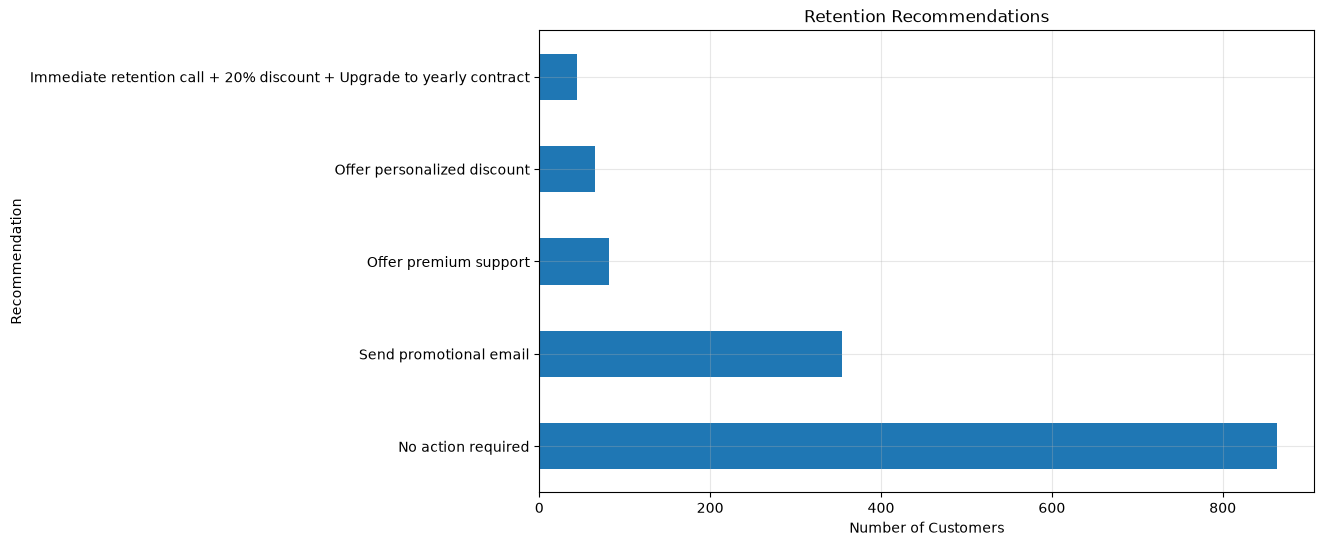

In [75]:
import matplotlib.pyplot as plt

risk_df["Recommendation"].value_counts().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Retention Recommendations")
plt.xlabel("Number of Customers")
plt.ylabel("Recommendation")

plt.grid(alpha=0.3)

plt.show()

In [76]:
dashboard_df = risk_df.copy()

dashboard_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual Churn,Churn Probability,Risk Level,Recommendation
2196,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.034241,Low,No action required
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.716964,High,Offer personalized discount
3515,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.078194,Low,No action required
5162,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.427025,Medium,Send promotional email
4642,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.037081,Low,No action required


In [77]:
dashboard_df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Actual Churn',
       'Churn Probability', 'Risk Level', 'Recommendation'],
      dtype='str')

In [78]:
dashboard_df.to_csv(
    "../data/processed/dashboard_data.csv",
    index=False
)

print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.


In [79]:
import os

os.path.exists("../data/processed/dashboard_data.csv")

True